In [1]:
import sys
sys.path.append("../../..")
from utils.processing import json_file_access
from beir.datasets.data_loader import GenericDataLoader
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import pytrec_eval

c:\Users\marvi\.conda\envs\masterthesis\Lib\site-packages\beir\datasets\data_loader.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
rq1_ir_res = json_file_access("../../../05_results/rq1/results_rq1.json", "r")
corpus, queries, qrels = GenericDataLoader(data_folder="../../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [3]:
from collections import defaultdict
results_rq1 = defaultdict(dict)

for key, value in rq1_ir_res.items():
    for query, result in value.items():
        results_rq1[key][query] = []
        for i, doc_id in enumerate(result.keys()):
            results_rq1[key][query].append(doc_id)

In [4]:
res_all = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion"],
    "cs_core_node_number": [10,20,30]
}

# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all[cs + "_" + str(cs_core_no)] = json_file_access(f"../../../05_results/rq2/cs/kg1_results_rq2_cs_{cs}_{cs_core_no}_all_community.json","r")
res_all["RQ1" + "_" + str(0)] = results_rq1

In [5]:
evaluator = pytrec_eval.RelevanceEvaluator(qrels, {'recall.100000'})
recalls = defaultdict(dict)

for cs, cs_values in res_all.items():
    for ir_type, ir_values in cs_values.items():
        recall = 0.0
        fake_scores = defaultdict(dict)
        for query, docs in ir_values.items():
            for doc in docs:
                fake_scores[query][doc] = 0
        scores = evaluator.evaluate(fake_scores)
        for query_id in scores.keys():
            recall += scores[query_id]["recall_100000"]
        recall = recall / len(scores.keys())
        recalls[cs][ir_type] = recall

In [13]:
pd.DataFrame(recalls)

,LFMLocal_10,LFMLocal_20,LFMLocal_30,GCE_10,GCE_20,GCE_30,LocalTightnessExpansion_10,LocalTightnessExpansion_20,LocalTightnessExpansion_30
boolean,0.262269,0.320496,0.344473,0.313723,0.368575,0.404823,0.306549,0.334814,0.362878
bm25,0.335914,0.410618,0.467483,0.388755,0.468556,0.523901,0.401055,0.433546,0.454853
vector,0.386405,0.441709,0.485941,0.431358,0.495443,0.537549,0.425081,0.444333,0.485437
hybrid,0.407396,0.490273,0.545793,0.467029,0.549066,0.599933,0.454029,0.501131,0.536166


## Calc Density of relevant Qrels in Graph

In [6]:
from utils.cs_pipeline import GraphCS
import networkit as nk
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, mode, norm

In [7]:
node_df = pd.read_parquet("../../../03_data/preprocessed_data/nodes_beir_dbpedia.parquet")
kg1_edges = pd.read_parquet('../../../03_data/preprocessed_data/pagelink_edges_beir_dbpedia.parquet')
Graph = GraphCS(node_df, kg1_edges)

Building Graph from given Data...
Graph built


In [8]:
density = {}
for query in qrels.keys():
    rel_nodes = [doc  for doc in qrels[query].keys() if qrels[query][doc]>0]
    subG = nk.graphtools.subgraphFromNodes(Graph.G, Graph._convert_dbpedia_to_index(rel_nodes))
    density[query] = nk.graphtools.density(subG)

In [9]:
def approximate_pdf(data):
    kde = gaussian_kde(data)
    x_values = np.linspace(data.min(), data.max(), 1000)  # Define x-axis range
    pdf_values = kde(x_values)

    mean = np.mean(data)
    median_value = np.median(data)
    mode_value = mode(data)[0]
    return x_values, pdf_values, mean, median_value, mode_value

In [10]:
x_values, pdf_values, mean, median_value, mode_value = approximate_pdf(np.array(list(density.values())))

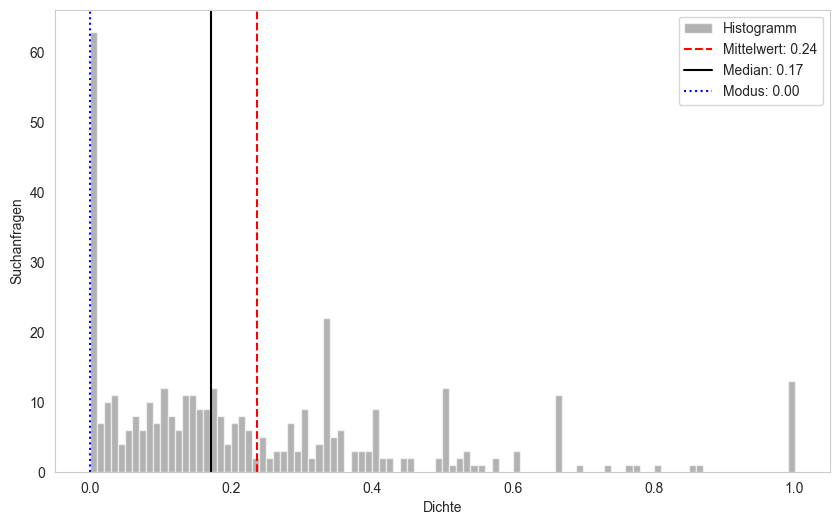

In [11]:
# Abbildung 30
plt.figure(figsize=(10,6))
plt.hist(np.array(list(density.values())), bins=100, density=False, alpha=0.6, color='gray', label='Histogramm')
plt.axvline(mean, color='r', linestyle='--', label=f'Mittelwert: {mean:.2f}')
plt.axvline(median_value, color='black', linestyle='-', label=f'Median: {median_value:.2f}')
plt.axvline(mode_value, color='b', linestyle=':', label=f'Modus: {mode_value:.2f}')
#plt.plot(x_values, pdf_values, label="PDF (Kernel-Dichte-Schätzung)", color="blue")
plt.xlabel("Dichte")
plt.ylabel("Suchanfragen")
plt.grid(False)
plt.legend()
plt.savefig("Abbildung_30.svg")

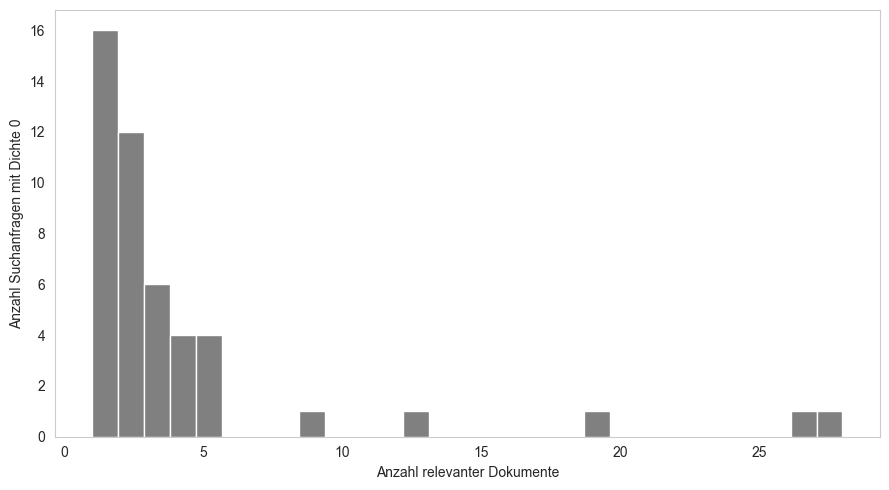

In [12]:
# Anhang B15
zero_dens = [key for key in density.keys() if density[key]==0.0]
docs = []
for query, relevances in qrels.items():
    if query in zero_dens:
        relevance_counter = 0
        for doc in relevances.keys():
            if relevances[doc] > 0:
                relevance_counter += 1
        docs.append(relevance_counter)
plt.figure(figsize=(9,5))
plt.hist(docs, bins=np.max(docs)+1, color = "gray");
plt.xlabel("Anzahl relevanter Dokumente")
plt.ylabel("Anzahl Suchanfragen mit Dichte 0")
plt.grid(False)
plt.tight_layout()
plt.savefig("Anhang_B15.svg")

In [5]:
import networkit as nk

# Anhang A4

In [ ]:
mean_density = defaultdict(dict)
#for cs, cs_values in res_all.items():
for cs in ["GCE_10","GCE_20","GCE_30","LFMLocal_10","LFMLocal_20","LFMLocal_30","LocalTightnessExpansion_10","LocalTightnessExpansion_20","LocalTightnessExpansion_30"]:
    #for ir_type, ir_values in cs_values.items():
    for ir_type in ["boolean"]:
        mean_density[cs][ir_type] = []
        for query, docs in res_all[cs][ir_type].items():
            subG = nk.graphtools.subgraphFromNodes(Graph.G, Graph._convert_dbpedia_to_index(docs))
            mean_density[cs][ir_type].append(nk.graphtools.density(subG))

In [10]:
print(np.mean(mean_density["LFMLocal_10"]["boolean"]))
print(np.mean(mean_density["LFMLocal_20"]["boolean"]))
print(np.mean(mean_density["LFMLocal_30"]["boolean"]))
print(np.mean(mean_density["LocalTightnessExpansion_10"]["boolean"]))
print(np.mean(mean_density["LocalTightnessExpansion_20"]["boolean"]))
print(np.mean(mean_density["LocalTightnessExpansion_30"]["boolean"]))
print(np.mean(mean_density["GCE_10"]["boolean"]))
print(np.mean(mean_density["GCE_20"]["boolean"]))
print(np.mean(mean_density["GCE_30"]["boolean"]))

0.036333471328845686
0.02513340201834858
0.01948725153417568
0.06303441952957702
0.04312874226207091
0.03440290375269116
0.03114549932046454
0.02126972796953993
0.015897380057755532


In [19]:
print(np.mean(mean_density["LFMLocal_10"]["hybrid"]))
print(np.mean(mean_density["LFMLocal_20"]["hybrid"]))
print(np.mean(mean_density["LFMLocal_30"]["hybrid"]))

0.03141657293925593
0.0207550927840126
0.01671255724960143


In [21]:
print(np.mean(mean_density["LFMLocal_10"]["vector"]))
print(np.mean(mean_density["LFMLocal_20"]["vector"]))
print(np.mean(mean_density["LFMLocal_30"]["vector"]))

0.03167463571563824
0.021213942679544368
0.017092239486649397


In [17]:
print(np.mean(mean_density["LocalTightnessExpansion_10"]["hybrid"]))
print(np.mean(mean_density["LocalTightnessExpansion_20"]["hybrid"]))
print(np.mean(mean_density["LocalTightnessExpansion_30"]["hybrid"]))

0.06110092482215513
0.04561842888725407
0.03746493498628935


In [23]:
print(np.mean(mean_density["LocalTightnessExpansion_10"]["vector"]))
print(np.mean(mean_density["LocalTightnessExpansion_20"]["vector"]))
print(np.mean(mean_density["LocalTightnessExpansion_30"]["vector"]))

0.05742777878213426
0.03864535770071352
0.030567429318860695


In [12]:
print(np.mean(mean_density["GCE_10"]["hybrid"]))
print(np.mean(mean_density["GCE_20"]["hybrid"]))
print(np.mean(mean_density["GCE_30"]["hybrid"]))

0.027078210906472593
0.01825655306584535
0.014519826123831547


In [26]:
print(np.mean(mean_density["GCE_10"]["vector"]))
print(np.mean(mean_density["GCE_20"]["vector"]))
print(np.mean(mean_density["GCE_30"]["vector"]))

0.027817949513106004
0.017900799145377816
0.014755437495623124
